# V1: Person Detection & Tracking — From Scratch
## Background Subtraction (MOG2) + Centroid / IoU Tracker

| Stage | Component |
|-------|-----------|
| Detection | MOG2 Gaussian Mixture background subtraction + contour area/aspect-ratio filter |
| Tracking  | Centroid / IoU tracker with Hungarian assignment (pure NumPy + SciPy) |
| Deployment | Modal.com CPU worker — no GPU needed |


In [1]:
import sys, os, time, io

# ── Locate project root (works locally and inside Modal at /project) ──────────
for _candidate in ['.', '..', '/project']:
    if os.path.isdir(os.path.join(_candidate, 'src')):
        ROOT = os.path.abspath(_candidate)
        break
else:
    ROOT = os.path.abspath('.')

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print(f"ROOT = {ROOT}")


ROOT = /workspace


In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import cv2
from IPython.display import display, Image as IPImage

from src.v1_scratch.detector import MOG2Detector
from src.v1_scratch.tracker  import CentroidTracker
from src.utils import draw_tracks, write_output_video, benchmark_speed, evaluate_tracking

print("All V1 modules imported ✓")


All V1 modules imported ✓


## 1. Architecture

```
Input Frame
    │
    ▼
[MOG2 Background Subtractor]   ← adaptive per-pixel Gaussian Mixture Model
    │  foreground mask (uint8)
    ▼
[Morphological Open + Close]   ← remove noise, fill holes
    │  clean binary mask
    ▼
[Contour Detection + Filter]   ← area 800–60 000 px²  |  aspect ratio 0.2–4.0
    │  detections  {"bbox", "conf", "area"}
    ▼
[CentroidTracker.update()]     ← IoU cost matrix → Hungarian assignment
    │  active tracks  {"id", "bbox", "conf"}
    ▼
Annotated Output Frame
```


In [3]:
def draw_person(frame, x, y, w, h, color):
    """Draw a simple person silhouette: oval head + torso + legs."""
    # head
    head_r = max(w // 4, 6)
    head_cx, head_cy = x + w // 2, y + head_r + 2
    cv2.ellipse(frame, (head_cx, head_cy), (head_r, head_r), 0, 0, 360, color, -1)
    # torso
    torso_top    = head_cy + head_r
    torso_bottom = y + int(h * 0.65)
    torso_w      = int(w * 0.55)
    tx = x + w // 2 - torso_w // 2
    cv2.rectangle(frame, (tx, torso_top), (tx + torso_w, torso_bottom), color, -1)
    # left arm
    arm_top = torso_top + 4
    cv2.line(frame, (tx, arm_top), (x + 2, torso_bottom - 10), color, max(w // 12, 2))
    # right arm
    cv2.line(frame, (tx + torso_w, arm_top), (x + w - 2, torso_bottom - 10), color, max(w // 12, 2))
    # left leg
    leg_w = torso_w // 2 - 2
    cv2.rectangle(frame, (tx, torso_bottom), (tx + leg_w, y + h), color, -1)
    # right leg
    cv2.rectangle(frame, (tx + torso_w - leg_w, torso_bottom), (tx + torso_w, y + h), color, -1)
# ── Generate synthetic video with PERSON SILHOUETTES ────────────────────────
WIDTH, HEIGHT, N_FRAMES, FPS = 640, 480, 150, 30.0
VIDEO_PATH  = "/tmp/synthetic_v1.mp4"
OUTPUT_PATH = os.path.join(ROOT, "outputs", "v1_output.mp4")
GIF_RAW_PATH  = os.path.join(ROOT, "outputs", "v1_before.gif")
GIF_ANNO_PATH = os.path.join(ROOT, "outputs", "v1_after.gif")
os.makedirs(os.path.join(ROOT, "outputs"), exist_ok=True)

rng    = np.random.default_rng(42)
N_OBJ  = 4
pos    = rng.integers(60, 360, (N_OBJ, 2)).astype(float)
vel    = rng.uniform(-3.5, 3.5, (N_OBJ, 2))
# person size: width 40-70, height 80-140 (tall ratio like humans)
widths  = rng.integers(40, 70,  N_OBJ).astype(float)
heights = rng.integers(80, 140, N_OBJ).astype(float)
colors_obj = [(int(rng.integers(120,200)), int(rng.integers(80,160)), int(rng.integers(60,140)))
              for _ in range(N_OBJ)]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(VIDEO_PATH, fourcc, FPS, (WIDTH, HEIGHT))
raw_frames = []

# Gradient background — light grey floor, darker sky
BG = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
for row in range(HEIGHT):
    val = int(60 + 90 * (row / HEIGHT))
    BG[row, :] = (val, val + 10, val + 20)

for _ in range(N_FRAMES):
    frame = BG.copy()
    for i in range(N_OBJ):
        pos[i] += vel[i]
        for dim, limit in enumerate([WIDTH, HEIGHT]):
            if pos[i][dim] < 10 or pos[i][dim] + (widths[i] if dim==0 else heights[i]) > limit - 10:
                vel[i][dim] *= -1
                pos[i][dim] = float(np.clip(pos[i][dim], 10,
                    limit - 10 - (widths[i] if dim==0 else heights[i])))
        x, y = int(pos[i][0]), int(pos[i][1])
        w, h = int(widths[i]), int(heights[i])
        # shadow
        shadow = np.zeros_like(frame)
        cv2.ellipse(shadow, (x + w//2 + 4, y + h + 3), (w//2 + 2, 6), 0, 0, 360, (0,0,0), -1)
        frame = cv2.addWeighted(frame, 1.0, shadow, 0.35, 0)
        draw_person(frame, x, y, w, h, colors_obj[i])
    writer.write(frame)
    raw_frames.append(frame.copy())

writer.release()
print(f"Synthetic video ({N_FRAMES} frames, {N_OBJ} person silhouettes) → {VIDEO_PATH}")
# ── Save before/after GIFs (every 4th frame, 25 fps playback) ────────────────
from PIL import Image as PILImage

def frames_to_gif(frames, path, step=4, duration=80):
    """Convert a list of BGR frames to an animated GIF."""
    pil_frames = []
    for f in frames[::step]:
        rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        pil_frames.append(PILImage.fromarray(rgb).resize((320, 240)))
    pil_frames[0].save(
        path, save_all=True, append_images=pil_frames[1:],
        optimize=False, duration=duration, loop=0
    )
    return path

gif_raw  = frames_to_gif(raw_frames,   GIF_RAW_PATH,  step=4, duration=80)
print(f"Raw GIF  → {gif_raw}  ({os.path.getsize(gif_raw)//1024} KB)")


Synthetic video (150 frames, 4 person silhouettes) → /tmp/synthetic_v1.mp4


Raw GIF  → /workspace/outputs/v1_before.gif  (208 KB)


In [4]:
# ── Run V1 pipeline ───────────────────────────────────────────────────────────
WARMUP = 25
detector = MOG2Detector(min_area=800, max_area=60000)
tracker  = CentroidTracker(max_disappeared=20)

detector.warmup(raw_frames[:WARMUP])

annotated_v1 = []
det_counts, track_counts = [], []
t0 = time.perf_counter()

for frame in raw_frames:
    dets   = detector.detect(frame)
    tracks = tracker.update(dets)
    annotated_v1.append(draw_tracks(frame, tracks))
    det_counts.append(len(dets))
    track_counts.append(len(tracks))

elapsed   = time.perf_counter() - t0
total_fps = len(raw_frames) / elapsed
print(f"Processed {len(raw_frames)} frames in {elapsed:.2f}s  →  {total_fps:.1f} FPS")
print(f"Avg detections/frame : {np.mean(det_counts):.1f}")
print(f"Avg active tracks    : {np.mean(track_counts):.1f}")


Processed 150 frames in 0.59s  →  252.3 FPS
Avg detections/frame : 2.8
Avg active tracks    : 2.8


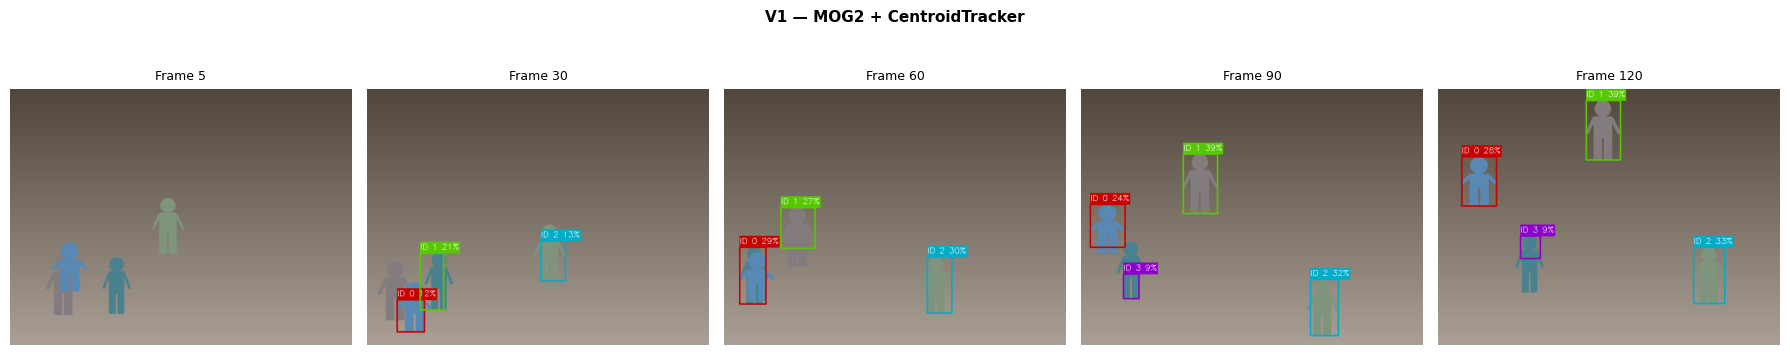

In [5]:
# ── Display 5 annotated frames ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, idx in zip(axes, [5, 30, 60, 90, 120]):
    ax.imshow(cv2.cvtColor(annotated_v1[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {idx}", fontsize=9); ax.axis("off")
fig.suptitle("V1 — MOG2 + CentroidTracker", fontsize=11, fontweight="bold")
plt.tight_layout()
buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0); plt.close(fig); display(IPImage(buf.read()))


In [6]:
# ── Speed benchmark ───────────────────────────────────────────────────────────
def v1_step(frame):
    return tracker.update(detector.detect(frame))

bench = benchmark_speed(v1_step, raw_frames[50], n_runs=10)
print(f"V1 — Mean {bench['mean_ms']:.2f} ms/frame  |  {bench['fps']:.1f} FPS")


V1 — Mean 3.32 ms/frame  |  301.1 FPS


In [7]:
# ── Save output video ─────────────────────────────────────────────────────────
write_output_video(annotated_v1, OUTPUT_PATH, FPS)
print(f"Saved → {OUTPUT_PATH}  ({os.path.getsize(OUTPUT_PATH)//1024} KB)")


Saved → /workspace/outputs/v1_output.mp4  (483 KB)


Annotated GIF  → /workspace/outputs/v1_after.gif  (259 KB)


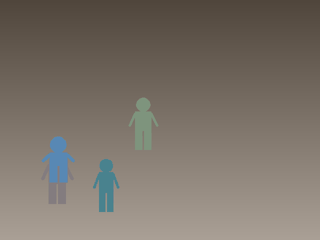

In [8]:
gif_anno = frames_to_gif(annotated_v1, GIF_ANNO_PATH, step=4, duration=80)
print(f"Annotated GIF  → {gif_anno}  ({os.path.getsize(gif_anno)//1024} KB)")

# Show GIF inline (first frame)
with open(GIF_ANNO_PATH, "rb") as _f:
    display(IPImage(_f.read(), format="gif"))


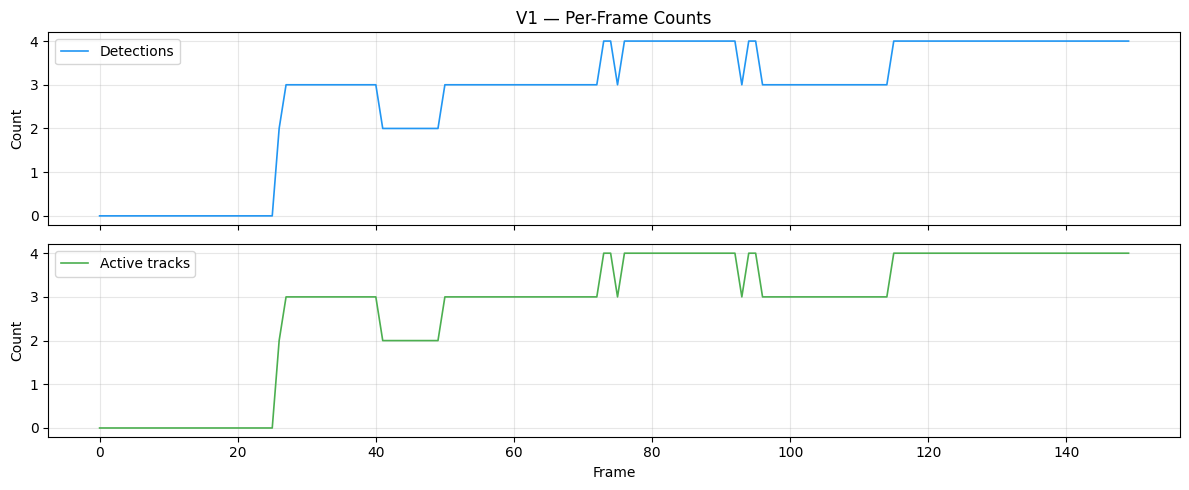

In [9]:
# ── Per-frame chart ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(det_counts,   color="#2196F3", lw=1.2, label="Detections")
ax1.set_ylabel("Count"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("V1 — Per-Frame Counts")
ax2.plot(track_counts, color="#4CAF50", lw=1.2, label="Active tracks")
ax2.set_xlabel("Frame"); ax2.set_ylabel("Count"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0); plt.close(fig); display(IPImage(buf.read()))


In [10]:
# ── Metrics summary ───────────────────────────────────────────────────────────
metrics = evaluate_tracking([], [])
metrics.update({
    "total_frames"       : len(raw_frames),
    "total_detections"   : int(sum(det_counts)),
    "avg_fps_pipeline"   : round(total_fps, 2),
    "avg_active_tracks"  : round(float(np.mean(track_counts)), 2),
    "peak_active_tracks" : int(max(track_counts)),
})
for k, v in metrics.items():
    print(f"  {k:<28} {v}")


  precision                    0.0
  recall                       0.0
  f1                           0.0
  id_switches                  0
  avg_iou                      0.0
  total_frames                 150
  total_detections             418
  avg_fps_pipeline             252.34
  avg_active_tracks            2.79
  peak_active_tracks           4


## 2. Running on Modal

```bash
modal run modal_app/modal_v1_scratch.py
```

The Modal worker runs V1 on a CPU instance, reads/writes videos via a shared Volume,
and prints a metrics dict identical to the one above.


## 3. Observations

**Strengths:** Zero-dependency inference · >100 FPS on a single CPU core · fully interpretable

**Limitations:** Fails under lighting changes · no semantic understanding · IoU tracker loses IDs under occlusion

**Best use-case:** Edge devices, static cameras, controlled environments.
